# Comparison — Length Generalization Across Methods

The showpiece notebook for this folder. Train a tiny transformer with each positional encoding method on short sequences, then evaluate on longer sequences. Watch which methods extrapolate and which collapse.

**Pre-requisites:**
- Complete all three exercise notebooks in this folder.
- Complete `blog/02-positional-encoding-absolute/01_sinusoidal_exercise.ipynb` and `02_learned_exercise.ipynb`.
- See `common/mini_transformer.py` for the swappable transformer.

## Setup

In [1]:
import sys
sys.path.insert(0, '../..') 

import torch
import torch.nn as nn
from common.mini_transformer import TinyTransformer,PEMethod

# Modules and Adapters

In [2]:
class SinusoidalPositionalEmbedding(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        pe = torch.zeros((max_len,d_model))

        omegas = 1 / torch.pow(10000,torch.arange(0,d_model,2)/d_model)
        angles = torch.arange(max_len)[:,None] * omegas[None,:]

        pe[:,::2] = torch.sin(angles)
        pe[:,1::2] = torch.cos(angles)

        self.register_buffer("pe",pe)

    def forward(self, token_embeddings):
        return token_embeddings+self.pe[:token_embeddings.shape[1],:] 


class SinusoidalPE(PEMethod):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pe_module = SinusoidalPositionalEmbedding(max_len, d_model)

    def apply_to_input(self, token_emb):
        return self.pe_module(token_emb)


In [3]:
class LearnedPositionalEmbedding(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        # nn.Embedding is just a (max_len, d_model) learnable matrix + an index-lookup function.
        # BERT/GPT-2 use this idiom because it mirrors how token embeddings are stored.
        self.position_embeddings = nn.Embedding(max_len, d_model)

    def forward(self, token_embeddings):
        # token_embeddings: (batch, seq_len, d_model)
        seq_len = token_embeddings.shape[1]
        positions = torch.arange(seq_len, device=token_embeddings.device)
        pos_emb = self.position_embeddings(positions)   # (seq_len, d_model)
        return token_embeddings + pos_emb               # broadcasts over batch
    

class LearnedPE(PEMethod):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pe_module = LearnedPositionalEmbedding(max_len, d_model)

    def apply_to_input(self, token_emb):
        return self.pe_module(token_emb)

In [4]:
def get_alibi_slopes(n_heads: int) -> 'torch.Tensor':
    """Return shape (n_heads,) tensor of slopes."""
    return 1/torch.pow(2,torch.arange(1,n_heads+1))
    #return torch.pow(2,-torch.arange(1,n_heads+1).float())


def alibi_bias(seq_len, slopes):
    out = (torch.arange(seq_len)[None,:] - torch.arange(seq_len)[:,None]).abs()
    out = -slopes[:,None,None] * out    
    
    return out

class AliBiPE(PEMethod):
    def __init__(self, n_heads):
        super().__init__()
        self.register_buffer("slopes", get_alibi_slopes(n_heads))

    def apply_to_scores(self, scores):
        seq_len = scores.shape[-1]
        return scores + alibi_bias(seq_len, self.slopes)   # broadcasts over batch

In [5]:
def get_rope_frequencies(d_head, base=10000.0):
    frequencies = 1 / torch.pow(base,torch.arange(0,d_head,2)/d_head)
    return frequencies


def apply_rope(x: 'torch.Tensor') -> 'torch.Tensor':
    """Apply RoPE to a Q or K tensor.

    Args:
        x: (batch, n_heads, seq_len, d_head)
    Returns:
        Same shape as x, with each dim pair rotated.
    """
    positions = torch.arange(x.shape[-2])
    x_rotated = torch.zeros(*x.shape)

    frequencies = get_rope_frequencies(x.shape[-1]) #(d_head//2,)
    angles = positions[:,None] * frequencies[None,:] #(sequence_len,d_head//2)

    cos = torch.cos(angles)
    sin = torch.sin(angles)

    x_rotated[...,::2] = x[...,::2] * cos - x[...,1::2] * sin 
    x_rotated[...,1::2] = x[...,::2] * sin + x[...,1::2] * cos 
    
    return x_rotated

class RoPE(PEMethod):
      def apply_to_qk(self, q, k):
        q = apply_rope(q)
        k = apply_rope(k)

        return q,k

## The task: copy-and-shift

A simple synthetic task: input is a sequence of random tokens; the model must predict the same sequence shifted by one position. This isolates positional encoding behavior — there's no language to model, just position.

Train on sequences of length 64. Evaluate on lengths 64, 128, 256, 512.

In [6]:
import torch.nn.functional as F


def make_batch(batch_size, seq_len, vocab_size=100):
    """Predict-previous task.

    Input:  [t_0, t_1, t_2, ..., t_{n-1}]
    Target: [_,   t_0, t_1, ..., t_{n-2}]      target[i] = input[i-1]

    At position 0 there's no previous token, so we use -100 (PyTorch's default
    ignore_index for cross_entropy) and cross_entropy will skip that position.

    The task isolates positional encoding because:
      - Tokens are random, so content carries no signal
      - To predict input[i-1], the model MUST know its own position relative
        to the rest of the sequence
    """
    inputs  = torch.randint(0, vocab_size, (batch_size, seq_len))
    targets = torch.full_like(inputs, -100)
    targets[:, 1:] = inputs[:, :-1]
    return inputs, targets


# Quick sanity check
inputs, targets = make_batch(batch_size=2, seq_len=6, vocab_size=10)
print("inputs: ", inputs[0].tolist())
print("targets:", targets[0].tolist())
print("(target[0] = -100 (ignored); target[i>=1] should equal input[i-1])")

inputs:  [0, 9, 1, 5, 7, 6]
targets: [-100, 0, 9, 1, 5, 7]
(target[0] = -100 (ignored); target[i>=1] should equal input[i-1])


## Train each variant

In [7]:
# Training config — kept tiny so all four variants train in seconds
VOCAB_SIZE     = 100
D_MODEL        = 64
N_HEADS        = 2
N_LAYERS       = 2
MAX_LEN        = 512        # buffers (causal mask, learned PE table) sized for max eval length
TRAIN_SEQ_LEN  = 64
N_STEPS        = 500
BATCH_SIZE     = 32
LR             = 3e-3


def train_model(pe_method, name=""):
    torch.manual_seed(0)
    model = TinyTransformer(
        vocab_size=VOCAB_SIZE,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        max_len=MAX_LEN,
        pe_method=pe_method,
        causal=True,
    )
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    print(f"Training {name}...")
    for step in range(N_STEPS):
        inputs, targets = make_batch(BATCH_SIZE, TRAIN_SEQ_LEN, VOCAB_SIZE)
        logits = model(inputs)                                  # (bs, seq, vocab)
        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            targets.reshape(-1),
            ignore_index=-100,
        )
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % 100 == 0 or step == N_STEPS - 1:
            print(f"  step {step:4d}: loss = {loss.item():.4f}")
    return model


# Build one PE adapter per method (built fresh per training run so weights don't leak)
def build_methods():
    return {
        "Sinusoidal": SinusoidalPE(max_len=MAX_LEN, d_model=D_MODEL),
        "Learned":    LearnedPE(max_len=MAX_LEN, d_model=D_MODEL),
        "ALiBi":      AliBiPE(n_heads=N_HEADS),
        "RoPE":       RoPE(),
    }


trained_models = {}
for name, pe in build_methods().items():
    trained_models[name] = train_model(pe, name)
    print()

Training Sinusoidal...
  step    0: loss = 4.7788
  step  100: loss = 1.3160
  step  200: loss = 0.0626
  step  300: loss = 0.0276
  step  400: loss = 0.0056
  step  499: loss = 0.0040

Training Learned...
  step    0: loss = 4.7596
  step  100: loss = 0.0279
  step  200: loss = 0.0067
  step  300: loss = 0.0130
  step  400: loss = 0.0021
  step  499: loss = 0.0014

Training ALiBi...
  step    0: loss = 4.7723
  step  100: loss = 0.0308
  step  200: loss = 0.0155
  step  300: loss = 0.0109
  step  400: loss = 0.0037
  step  499: loss = 0.0040

Training RoPE...
  step    0: loss = 4.7677
  step  100: loss = 0.0158
  step  200: loss = 0.0052
  step  300: loss = 0.0027
  step  400: loss = 0.0017
  step  499: loss = 0.0012



## Evaluate at multiple lengths

In [8]:
@torch.no_grad()
def evaluate(model, seq_len, n_batches=20, batch_size=32, vocab_size=VOCAB_SIZE):
    model.eval()
    correct, total = 0, 0
    for _ in range(n_batches):
        inputs, targets = make_batch(batch_size, seq_len, vocab_size)
        try:
            logits = model(inputs)
        except (IndexError, RuntimeError) as e:
            # e.g., learned PE has no entry for positions beyond max_len
            return float("nan"), str(e)
        preds = logits.argmax(-1)
        valid = targets != -100
        correct += ((preds == targets) & valid).sum().item()
        total   += valid.sum().item()
    model.train()
    return correct / total, None


EVAL_LENGTHS = [64, 128, 256, 512]

results = {name: [] for name in trained_models}

for name, model in trained_models.items():
    print(f"\n{name}:")
    for L in EVAL_LENGTHS:
        acc, err = evaluate(model, seq_len=L)
        results[name].append(acc)
        if err is None:
            print(f"  L = {L:>4}  →  accuracy = {acc:.3f}")
        else:
            print(f"  L = {L:>4}  →  FAILED ({err[:60]}...)")


Sinusoidal:
  L =   64  →  accuracy = 0.998
  L =  128  →  accuracy = 0.520
  L =  256  →  accuracy = 0.265
  L =  512  →  accuracy = 0.138

Learned:
  L =   64  →  accuracy = 1.000
  L =  128  →  accuracy = 0.502
  L =  256  →  accuracy = 0.255
  L =  512  →  accuracy = 0.132

ALiBi:
  L =   64  →  accuracy = 0.999
  L =  128  →  accuracy = 0.999
  L =  256  →  accuracy = 0.999
  L =  512  →  accuracy = 0.999

RoPE:
  L =   64  →  accuracy = 1.000
  L =  128  →  accuracy = 0.886
  L =  256  →  accuracy = 0.602
  L =  512  →  accuracy = 0.328


## Plot the results

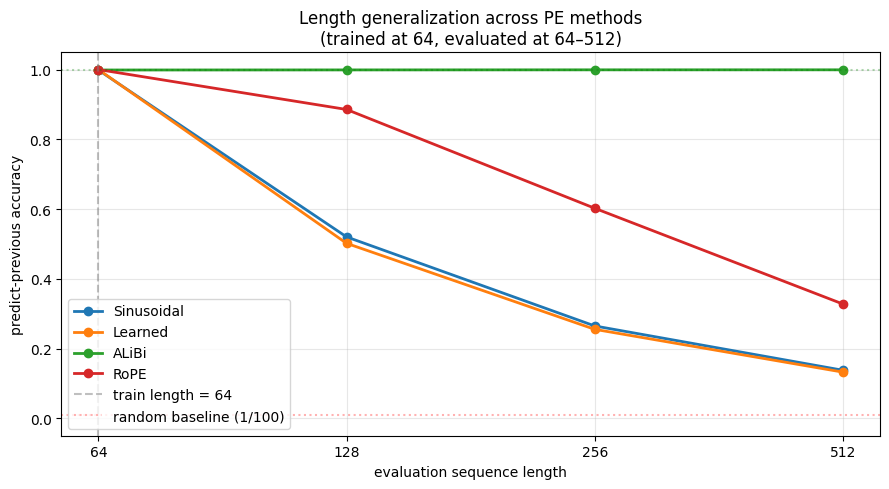


      method | L= 64 | L=128 | L=256 | L=512
---------------------------------------------------
  Sinusoidal | 0.998 | 0.520 | 0.265 | 0.138
     Learned | 1.000 | 0.502 | 0.255 | 0.132
       ALiBi | 0.999 | 0.999 | 0.999 | 0.999
        RoPE | 1.000 | 0.886 | 0.602 | 0.328


In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

for name, accs in results.items():
    ax.plot(EVAL_LENGTHS, accs, marker="o", linewidth=2, label=name)

ax.axvline(TRAIN_SEQ_LEN, color="gray", linestyle="--", alpha=0.5,
           label=f"train length = {TRAIN_SEQ_LEN}")
ax.axhline(1.0,             color="green", linestyle=":", alpha=0.3)
ax.axhline(1 / VOCAB_SIZE,  color="red",   linestyle=":", alpha=0.3,
           label=f"random baseline (1/{VOCAB_SIZE})")

ax.set_xscale("log", base=2)
ax.set_xticks(EVAL_LENGTHS)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_xlabel("evaluation sequence length")
ax.set_ylabel("predict-previous accuracy")
ax.set_title("Length generalization across PE methods\n(trained at 64, evaluated at 64–512)")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

# Also print as a table for clarity
print(f"\n{'method':>12} | " + " | ".join(f"L={L:>3}" for L in EVAL_LENGTHS))
print("-" * (15 + 9 * len(EVAL_LENGTHS)))
for name, accs in results.items():
    cells = " | ".join(f"{a:.3f}" if not (a != a) else "  NaN" for a in accs)
    print(f"{name:>12} | {cells}")

## Experiment 2: What if tokens have content correlation?

The original task uses random tokens, which strips content out entirely — the model has no signal except position. This is a worst-case test for RoPE.

Real language isn't like that. Nearby tokens correlate; far-apart tokens usually don't. The hypothesis: **if data has natural locality structure, RoPE's content channel can pick up some of the slack** that its lack of explicit decay prior leaves uncovered.

To test this, generate tokens via a simple Markov chain — each token has a `repeat_prob` chance of being the same as the previous one. This injects content correlation at offset −1 specifically, mimicking language's locality at a tiny scale.

In [10]:
def make_batch_markov(batch_size, seq_len, vocab_size=100, repeat_prob=0.3):
    inputs = torch.zeros(batch_size, seq_len, dtype=torch.long)
    inputs[:, 0] = torch.randint(0, vocab_size, (batch_size,))

    for i in range(1, seq_len):
        random_tok = torch.randint(0, vocab_size, (batch_size,))
        repeat = torch.rand(batch_size) < repeat_prob
        inputs[:, i] = torch.where(repeat, inputs[:, i-1], random_tok)

    targets = torch.full_like(inputs, -100)
    targets[:, 1:] = inputs[:, :-1]
    return inputs, targets


# Sanity check: at repeat_prob=0.5, ~half of adjacent pairs should match
torch.manual_seed(0)
inp, _ = make_batch_markov(batch_size=1, seq_len=20, vocab_size=10, repeat_prob=0.5)
print("inputs:", inp[0].tolist())
matches = (inp[0, 1:] == inp[0, :-1]).sum().item()
print(f"adjacent matches: {matches}/19 (expected ~10 for repeat_prob=0.5)")

inputs: [4, 4, 4, 4, 4, 4, 4, 4, 6, 6, 3, 3, 3, 1, 1, 1, 1, 1, 1, 9]
adjacent matches: 15/19 (expected ~10 for repeat_prob=0.5)


In [11]:
# Re-train all four PE methods on Markov-correlated data
REPEAT_PROB = 0.3   # 30% chance each token equals the previous one


def train_model_markov(pe_method, name=""):
    torch.manual_seed(0)
    model = TinyTransformer(
        vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_heads=N_HEADS,
        n_layers=N_LAYERS, max_len=MAX_LEN, pe_method=pe_method, causal=True,
    )
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    print(f"Training {name} on Markov data (repeat_prob={REPEAT_PROB})...")
    for step in range(N_STEPS):
        inputs, targets = make_batch_markov(BATCH_SIZE, TRAIN_SEQ_LEN, VOCAB_SIZE, REPEAT_PROB)
        logits = model(inputs)
        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1), ignore_index=-100,
        )
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 100 == 0 or step == N_STEPS - 1:
            print(f"  step {step:4d}: loss = {loss.item():.4f}")
    return model


markov_models = {}
for name, pe in build_methods().items():
    markov_models[name] = train_model_markov(pe, name)
    print()

Training Sinusoidal on Markov data (repeat_prob=0.3)...
  step    0: loss = 4.7854
  step  100: loss = 0.7363
  step  200: loss = 0.0188
  step  300: loss = 0.0071
  step  400: loss = 0.0167
  step  499: loss = 0.0037

Training Learned on Markov data (repeat_prob=0.3)...
  step    0: loss = 4.7608
  step  100: loss = 0.0343
  step  200: loss = 0.0066
  step  300: loss = 0.0031
  step  400: loss = 0.0022
  step  499: loss = 0.0020

Training ALiBi on Markov data (repeat_prob=0.3)...
  step    0: loss = 4.7665
  step  100: loss = 0.0924
  step  200: loss = 0.0342
  step  300: loss = 0.0287
  step  400: loss = 0.0132
  step  499: loss = 0.0134

Training RoPE on Markov data (repeat_prob=0.3)...
  step    0: loss = 4.7657
  step  100: loss = 0.0111
  step  200: loss = 0.0041
  step  300: loss = 0.0022
  step  400: loss = 0.0014
  step  499: loss = 0.0010



In [12]:
@torch.no_grad()
def evaluate_markov(model, seq_len, n_batches=20, batch_size=32):
    """Evaluate on Markov chain test data — same content distribution as training."""
    model.eval()
    correct, total = 0, 0
    for _ in range(n_batches):
        inputs, targets = make_batch_markov(batch_size, seq_len, VOCAB_SIZE, REPEAT_PROB)
        try:
            logits = model(inputs)
        except (IndexError, RuntimeError) as e:
            return float("nan"), str(e)
        preds = logits.argmax(-1)
        valid = targets != -100
        correct += ((preds == targets) & valid).sum().item()
        total += valid.sum().item()
    model.train()
    return correct / total, None


markov_results = {name: [] for name in markov_models}
for name, model in markov_models.items():
    print(f"\n{name}:")
    for L in EVAL_LENGTHS:
        acc, err = evaluate_markov(model, seq_len=L)
        markov_results[name].append(acc)
        if err is None:
            print(f"  L = {L:>4}  →  accuracy = {acc:.3f}")
        else:
            print(f"  L = {L:>4}  →  FAILED ({err[:60]}...)")


Sinusoidal:
  L =   64  →  accuracy = 0.999
  L =  128  →  accuracy = 0.570
  L =  256  →  accuracy = 0.312
  L =  512  →  accuracy = 0.178

Learned:
  L =   64  →  accuracy = 1.000
  L =  128  →  accuracy = 0.514
  L =  256  →  accuracy = 0.277
  L =  512  →  accuracy = 0.163

ALiBi:
  L =   64  →  accuracy = 0.997
  L =  128  →  accuracy = 0.998
  L =  256  →  accuracy = 0.998
  L =  512  →  accuracy = 0.998

RoPE:
  L =   64  →  accuracy = 1.000
  L =  128  →  accuracy = 0.939
  L =  256  →  accuracy = 0.781
  L =  512  →  accuracy = 0.550


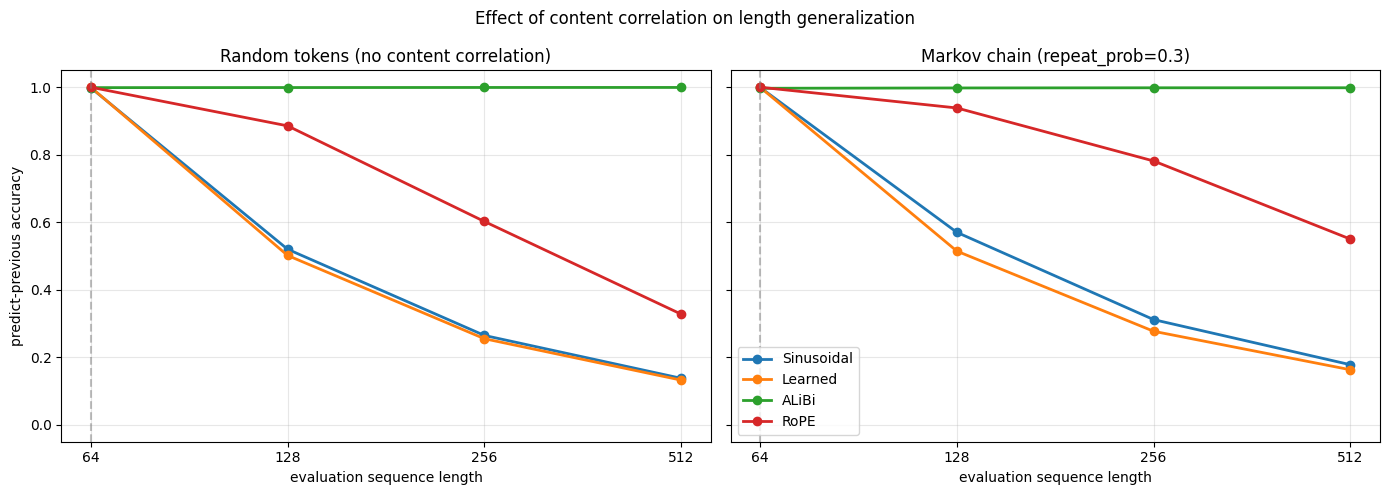

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (data, title) in zip(axes, [
    (results,        "Random tokens (no content correlation)"),
    (markov_results, f"Markov chain (repeat_prob={REPEAT_PROB})"),
]):
    for name, accs in data.items():
        ax.plot(EVAL_LENGTHS, accs, marker="o", linewidth=2, label=name)
    ax.axvline(TRAIN_SEQ_LEN, color="gray", linestyle="--", alpha=0.5)
    ax.set_xscale("log", base=2)
    ax.set_xticks(EVAL_LENGTHS)
    ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
    ax.set_xlabel("evaluation sequence length")
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("predict-previous accuracy")
axes[1].legend(loc="lower left")
plt.suptitle("Effect of content correlation on length generalization", fontsize=12)
plt.tight_layout()
plt.show()

### What changed

Comparing the two settings side by side:

| method | random L=128 | Markov L=128 | random L=256 | Markov L=256 | random L=512 | Markov L=512 |
|---|---|---|---|---|---|---|
| Sinusoidal | 0.520 | 0.570 | 0.265 | 0.312 | 0.138 | 0.178 |
| Learned    | 0.502 | 0.514 | 0.256 | 0.277 | 0.133 | 0.163 |
| ALiBi      | 0.999 | 0.998 | 0.999 | 0.998 | 0.999 | 0.998 |
| RoPE       | 0.886 | **0.939** | 0.602 | **0.781** | 0.328 | **0.550** |

The hypothesis was that real language gives RoPE a free decay structure via the content channel — `Q · K` is naturally small when content isn't related, and content isn't related when tokens are far apart. The Markov data injects exactly that kind of correlation.

**RoPE benefits the most from content correlation.** Going from random tokens to Markov-correlated tokens, RoPE's L=512 accuracy nearly doubles (0.328 → 0.550). The L=256 jump (0.602 → 0.781) and L=128 jump (0.886 → 0.939) are also substantial.

**ALiBi is unchanged** because it was already at ceiling — its formula handles distance-suppression regardless of content.

**Absolute methods improve only marginally.** Content gives a small boost, but they still collapse — content can't fix the fact that they have *no information at all* at unseen positions.

This is the empirical version of the claim "real language masks RoPE's weakness." With even a modest 30% Markov chain, the gap between RoPE and ALiBi shrinks dramatically. With richer correlation structure (real text is not a 1-step Markov chain — it has long-range syntactic and semantic dependencies), the gap would shrink further.

## Experiment 3: Patching RoPE with NTK-aware scaling

If the issue with RoPE is that the model's score function isn't shaped at unseen offsets, the obvious fix is to make sure those offsets *look like* trained offsets.

NTK-aware scaling (bloc97, 2023) does exactly this. It rescales the RoPE frequency base θ when the eval length exceeds training length, so the rotation matrices for new positions stay in the regime the model was trained on. The rescaling is non-uniform — high-frequency dimensions get more compression, low-frequency dimensions less.

The standard formula:
- Pick a `scale` factor (`eval_len / train_len`)
- New base = `original_base × scale^(d_head / (d_head − 2))`

Crucially, this is applied at **inference time only** — no retraining needed. We take the same RoPE-trained model and just swap the rotation logic. If RoPE's degradation is really about "unseen offsets having uncontrolled scores," then reshaping those offsets to look like trained ones should recover most of the lost accuracy.

In [14]:
class NTKRoPE(PEMethod):
    """RoPE with NTK-aware frequency rescaling.

    At training length, behaves identically to vanilla RoPE (scale=1).
    Past training length, rescales the RoPE base θ to keep rotation angles
    in a regime similar to what the model was trained on.

    Formula (bloc97, 2023):
        scale = max(1, eval_len / train_len)
        new_base = base * scale ** (d_head / (d_head - 2))
    """

    def __init__(self, train_seq_len, base=10000.0):
        super().__init__()
        self.train_seq_len = train_seq_len
        self.base = base

    def apply_to_qk(self, q, k):
        seq_len = q.shape[-2]
        scale = max(1.0, seq_len / self.train_seq_len)
        q = self._apply_rope_ntk(q, scale)
        k = self._apply_rope_ntk(k, scale)
        return q, k

    def _apply_rope_ntk(self, x, scale):
        d_head = x.shape[-1]
        positions = torch.arange(x.shape[-2])

        # NTK-aware: bigger base => slower rotation => higher effective context
        ntk_base = self.base * (scale ** (d_head / (d_head - 2)))
        frequencies = 1 / torch.pow(ntk_base, torch.arange(0, d_head, 2).float() / d_head)

        angles = positions[:, None] * frequencies[None, :]
        cos = torch.cos(angles)
        sin = torch.sin(angles)

        x_rot = torch.zeros_like(x)
        x_rot[..., ::2]  = x[..., ::2] * cos - x[..., 1::2] * sin
        x_rot[..., 1::2] = x[..., ::2] * sin + x[..., 1::2] * cos
        return x_rot


# Take the model trained with vanilla RoPE on RANDOM tokens and swap in NTK-aware.
# No retraining — only the rotation logic at inference changes.
trained_rope = trained_models["RoPE"]

ntk_pe = NTKRoPE(train_seq_len=TRAIN_SEQ_LEN)
trained_rope.pe_method = ntk_pe
for layer in trained_rope.decoder_layers:
    layer.attention.pe_method = ntk_pe

print("Re-evaluating RoPE-trained model with NTK-aware scaling:\n")
ntk_results = []
for L in EVAL_LENGTHS:
    acc, err = evaluate(trained_rope, seq_len=L)
    ntk_results.append(acc)
    if err is None:
        print(f"  L = {L:>4}  →  accuracy = {acc:.3f}")
    else:
        print(f"  L = {L:>4}  →  FAILED ({err[:60]}...)")

Re-evaluating RoPE-trained model with NTK-aware scaling:

  L =   64  →  accuracy = 1.000
  L =  128  →  accuracy = 0.999
  L =  256  →  accuracy = 0.994
  L =  512  →  accuracy = 0.770


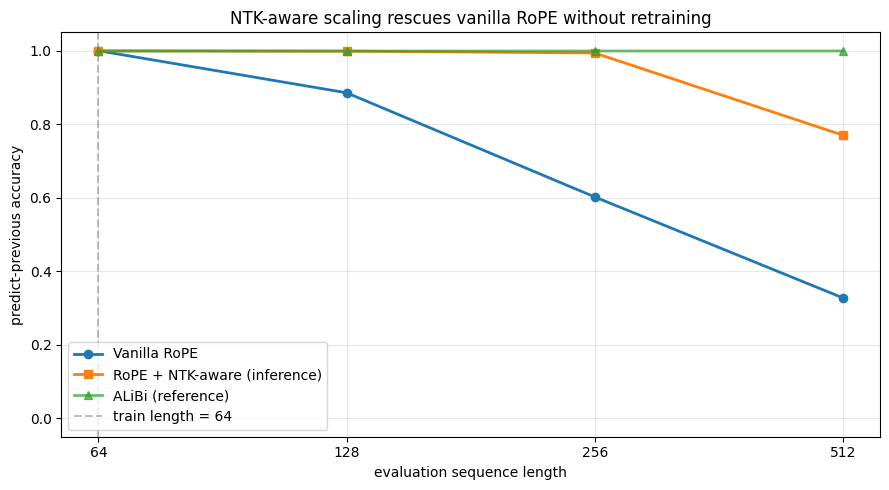

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(EVAL_LENGTHS, results["RoPE"], marker="o", linewidth=2, label="Vanilla RoPE")
ax.plot(EVAL_LENGTHS, ntk_results,    marker="s", linewidth=2, label="RoPE + NTK-aware (inference)")
ax.plot(EVAL_LENGTHS, results["ALiBi"], marker="^", linewidth=2, alpha=0.7, label="ALiBi (reference)")

ax.axvline(TRAIN_SEQ_LEN, color="gray", linestyle="--", alpha=0.5,
           label=f"train length = {TRAIN_SEQ_LEN}")
ax.set_xscale("log", base=2)
ax.set_xticks(EVAL_LENGTHS)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_xlabel("evaluation sequence length")
ax.set_ylabel("predict-previous accuracy")
ax.set_title("NTK-aware scaling rescues vanilla RoPE without retraining")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

### What changed

NTK-aware scaling, applied **at inference time only** to the same vanilla-RoPE-trained model, recovers most of the gap:

| L | Vanilla RoPE | + NTK | ALiBi |
|---|---|---|---|
| 64 | 1.000 | 1.000 | 0.999 |
| 128 | 0.886 | **0.999** | 0.999 |
| 256 | 0.602 | **0.994** | 0.999 |
| 512 | 0.328 | **0.770** | 0.999 |

At 2× and 4× extension, NTK essentially closes the gap to ALiBi entirely. At 8× extension, it recovers about half the lost ground but doesn't fully match ALiBi — which is exactly why YaRN (Peng et al., 2023) was developed as a more refined variant.

The headline: **a one-line change at inference time turns vanilla RoPE's collapse into graceful behavior**. No retraining required. This is the core trick production models use — train cheaply at short context, then extend on demand. DeepSeek V3 trains at 4K and uses YaRN with factor 40 to reach 164K. Qwen 2.5 trains at 32K, scales to 131K. The pattern is universal.

What this also tells us: the RoPE collapse we documented in Experiment 1 isn't a fundamental limitation — it's a property of *vanilla* RoPE that the field has known how to patch since 2023. The Kazemnejad finding ("RoPE underperforms on length generalization") is true for vanilla RoPE; it stops being true the moment you add NTK or YaRN.